# Multi-panel publication figure: 6 metrics in one PDF

This notebook keeps the **same modern design** as your single-metric figure, but creates **one PDF with six metrics** arranged in a **3 × 2 layout**.

## What it shows in each panel
- raw image-level points
- faint matched-image trajectories
- connected means across A–E
- mean ± 95% CI
- significant post-hoc brackets for selected C-focused comparisons

## Expected input files
```text
data/A_to_E_long_image_level_data.csv
data/A_to_E_repeated_measures_posthoc.csv
```

## Typical use
This is ideal when you want, for example, six CTA metrics in one clean paper figure.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
from scipy import stats


## 1. Configuration

In [2]:
LONG_CSV = "data/A_to_E_long_image_level_data.csv"
POSTHOC_CSV = "data/A_to_E_repeated_measures_posthoc.csv"

AOI = "CTA"
CONDITION_ORDER = ["A", "B", "C", "D", "E"]

# Choose exactly 6 metrics here
SELECTED_METRICS = [
    "VAI (%)",
    "TTFF (s)",
    "Time spent (s)",
    "Fixations",
    "Fix. duration (s)",
    "Revisits",
]

# Post-hoc comparisons to annotate if significant
SIGNIFICANCE_PAIRS = [
    ("A", "C"),
    ("B", "C"),
    ("C", "D"),
    ("C", "E"),
]

SHOW_MATCHED_LINES = True
SHOW_MEAN_LABELS = True

RANDOM_SEED = 42

OUTPUT_PNG = "CTA_6metrics_modern_same_design.png"
OUTPUT_PDF = "CTA_6metrics_modern_same_design.pdf"


## 2. Load data

In [3]:
for f in [LONG_CSV, POSTHOC_CSV]:
    if not Path(f).exists():
        raise FileNotFoundError(f"Could not find {f}")

long_df = pd.read_csv(LONG_CSV)
posthoc = pd.read_csv(POSTHOC_CSV)

for frame in [long_df, posthoc]:
    frame.columns = [str(c).replace("**", "").strip() for c in frame.columns]

long_df["value"] = pd.to_numeric(long_df["value"], errors="coerce")

print("Long data rows:", len(long_df))
print("Available AOIs:", sorted(long_df["AOI"].dropna().unique()))
print("Available metrics:", sorted(long_df["metric"].dropna().unique()))


Long data rows: 2400
Available AOIs: ['CTA', 'Headline', 'Product']
Available metrics: ['FFD (s)', 'Fix. duration (s)', 'Fixations', 'K-coefficient', 'Revisits', 'TTFF (s)', 'Time spent (s)', 'VAI (%)']


## 3. Validation

In [4]:
if len(SELECTED_METRICS) != 6:
    raise ValueError(
        f"You selected {len(SELECTED_METRICS)} metrics. "
        "Please provide exactly 6 metrics for a 3 × 2 figure."
    )

available_metrics = set(long_df["metric"].dropna().unique())
missing = [m for m in SELECTED_METRICS if m not in available_metrics]

if missing:
    raise ValueError(
        f"These selected metrics were not found in the long file: {missing}"
    )

print("Selected AOI:", AOI)
print("Selected metrics:")
for m in SELECTED_METRICS:
    print("-", m)


Selected AOI: CTA
Selected metrics:
- VAI (%)
- TTFF (s)
- Time spent (s)
- Fixations
- Fix. duration (s)
- Revisits


## 4. Helper functions

In [5]:
def get_focus(metric):
    df = long_df[
        (long_df["AOI"] == AOI)
        & (long_df["metric"] == metric)
        & (long_df["condition"].isin(CONDITION_ORDER))
    ].copy()

    df = df.dropna(subset=["value"])
    return df


def get_summary(focus_df):
    rows = []
    for cond in CONDITION_ORDER:
        vals = (
            focus_df.loc[focus_df["condition"] == cond, "value"]
            .dropna()
            .astype(float)
            .values
        )

        n = len(vals)
        mean = np.mean(vals) if n else np.nan
        sd = np.std(vals, ddof=1) if n > 1 else np.nan

        if n > 1:
            se = sd / np.sqrt(n)
            tcrit = stats.t.ppf(0.975, df=n - 1)
            ci = tcrit * se
        else:
            ci = np.nan

        rows.append({
            "condition": cond,
            "n": n,
            "mean": mean,
            "sd": sd,
            "ci95": ci,
            "lower": mean - ci if np.isfinite(ci) else np.nan,
            "upper": mean + ci if np.isfinite(ci) else np.nan,
        })

    return pd.DataFrame(rows)


def get_pivot(focus_df):
    return (
        focus_df.pivot(index="Img", columns="condition", values="value")
        .reindex(columns=CONDITION_ORDER)
    )


def get_pair_row(metric, g1, g2):
    mask = (
        (posthoc["AOI"] == AOI)
        & (posthoc["metric"] == metric)
        & (
            ((posthoc["group1"] == g1) & (posthoc["group2"] == g2))
            | ((posthoc["group1"] == g2) & (posthoc["group2"] == g1))
        )
    )

    rows = posthoc.loc[mask]
    return None if len(rows) == 0 else rows.iloc[0]


def format_q(q):
    if pd.isna(q):
        return ""
    if q < 0.001:
        return "q < .001"
    return f"q = {q:.3f}"


def deterministic_jitter(n, width=0.085):
    if n <= 1:
        return np.zeros(n)
    return np.linspace(-width, width, n)


def draw_metric_panel(ax, metric, idx, condition_colors):
    focus = get_focus(metric)
    summary = get_summary(focus)
    pivot = get_pivot(focus)

    x_positions = {c: i for i, c in enumerate(CONDITION_ORDER)}

    # subtle C emphasis
    c_x = x_positions["C"]
    ax.axvspan(c_x - 0.34, c_x + 0.34, alpha=0.035, zorder=0)

    # faint matched-image lines
    if SHOW_MATCHED_LINES:
        complete = pivot.dropna()
        for _, row in complete.iterrows():
            ax.plot(
                np.arange(len(CONDITION_ORDER)),
                row[CONDITION_ORDER].astype(float).values,
                linewidth=0.55,
                alpha=0.06,
                zorder=1
            )

    # raw points
    rng = np.random.default_rng(RANDOM_SEED + idx)

    for cond in CONDITION_ORDER:
        vals = (
            focus.loc[focus["condition"] == cond, "value"]
            .dropna()
            .astype(float)
            .sort_values()
            .values
        )

        x0 = x_positions[cond]
        jitter = deterministic_jitter(len(vals), width=0.085)

        # tiny random shuffle of order avoids visible ladders while
        # keeping the structure stable panel-to-panel
        if len(jitter) > 1:
            perm = rng.permutation(len(jitter))
            jitter = jitter[perm]

        ax.scatter(
            np.full(len(vals), x0) + jitter,
            vals,
            s=26,
            alpha=0.46,
            color=condition_colors[cond],
            edgecolors="white",
            linewidths=0.40,
            zorder=3
        )

    # mean line
    mean_values = [
        summary.loc[summary["condition"] == c, "mean"].iloc[0]
        for c in CONDITION_ORDER
    ]

    ax.plot(
        np.arange(len(CONDITION_ORDER)),
        mean_values,
        linewidth=2.25,
        alpha=0.88,
        zorder=4,
        path_effects=[
            pe.Stroke(linewidth=3.9, foreground="white"),
            pe.Normal()
        ]
    )

    # means + CI
    for _, r in summary.iterrows():
        cond = r["condition"]
        x = x_positions[cond]

        ax.errorbar(
            x,
            r["mean"],
            yerr=r["ci95"],
            fmt="o",
            markersize=7.8,
            capsize=4.5,
            capthick=1.3,
            elinewidth=1.8,
            color=condition_colors[cond],
            markeredgecolor="white",
            markeredgewidth=1.0,
            zorder=6
        )

    # panel-specific range
    data_min = float(focus["value"].min())
    data_max = float(focus["value"].max())
    data_range = max(1.0, data_max - data_min)

    # mean labels
    if SHOW_MEAN_LABELS:
        for _, r in summary.iterrows():
            cond = r["condition"]
            x = x_positions[cond]

            ax.text(
                x,
                r["upper"] + 0.020 * data_range,
                f'{r["mean"]:.1f}',
                ha="center",
                va="bottom",
                fontsize=7.6,
                fontweight="bold",
                color=condition_colors[cond],
                zorder=7,
                bbox=dict(
                    boxstyle="round,pad=0.16",
                    facecolor="white",
                    edgecolor="none",
                    alpha=0.88
                )
            )

    # significance brackets
    sig_pairs = []
    for g1, g2 in SIGNIFICANCE_PAIRS:
        row = get_pair_row(metric, g1, g2)
        if row is None:
            continue

        q = pd.to_numeric(
            pd.Series([row.get("q_posthoc_global_FDR")]),
            errors="coerce"
        ).iloc[0]
        sig = bool(row.get("significant_posthoc_global_FDR", False))

        if sig and np.isfinite(q):
            sig_pairs.append((g1, g2, q))

    base_y = data_max + 0.09 * data_range
    step = 0.075 * data_range
    bracket_h = 0.014 * data_range

    for k, (g1, g2, q) in enumerate(sig_pairs):
        x1 = x_positions[g1]
        x2 = x_positions[g2]
        y = base_y + k * step

        ax.plot(
            [x1, x1, x2, x2],
            [y, y + bracket_h, y + bracket_h, y],
            linewidth=1.0,
            zorder=8
        )

        ax.text(
            (x1 + x2) / 2,
            y + bracket_h + 0.007 * data_range,
            format_q(q),
            ha="center",
            va="bottom",
            fontsize=7.0,
            bbox=dict(
                boxstyle="round,pad=0.16",
                facecolor="white",
                edgecolor="none",
                alpha=0.96
            ),
            zorder=9
        )

    upper_limit = base_y + max(1, len(sig_pairs)) * step + 0.08 * data_range
    lower_limit = data_min - 0.04 * data_range

    ax.set_ylim(lower_limit, upper_limit)

    # clean metric title
    ax.set_title(metric, loc="left", fontweight="bold", fontsize=11, pad=9)

    # matched n
    matched_n = len(pivot.dropna())
    ax.text(
        0,
        1.005,
        f"matched images n = {matched_n}",
        transform=ax.transAxes,
        fontsize=7.8,
        va="bottom",
        alpha=0.68
    )

    ax.set_xticks(np.arange(len(CONDITION_ORDER)))
    ax.set_xticklabels(CONDITION_ORDER, fontweight="bold", fontsize=9)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_alpha(0.45)
    ax.spines["bottom"].set_alpha(0.45)

    ax.grid(axis="y", linewidth=0.55, alpha=0.10)
    ax.grid(axis="x", visible=False)
    ax.tick_params(axis="both", length=0)

    return focus


## 5. Create the 3 × 2 figure

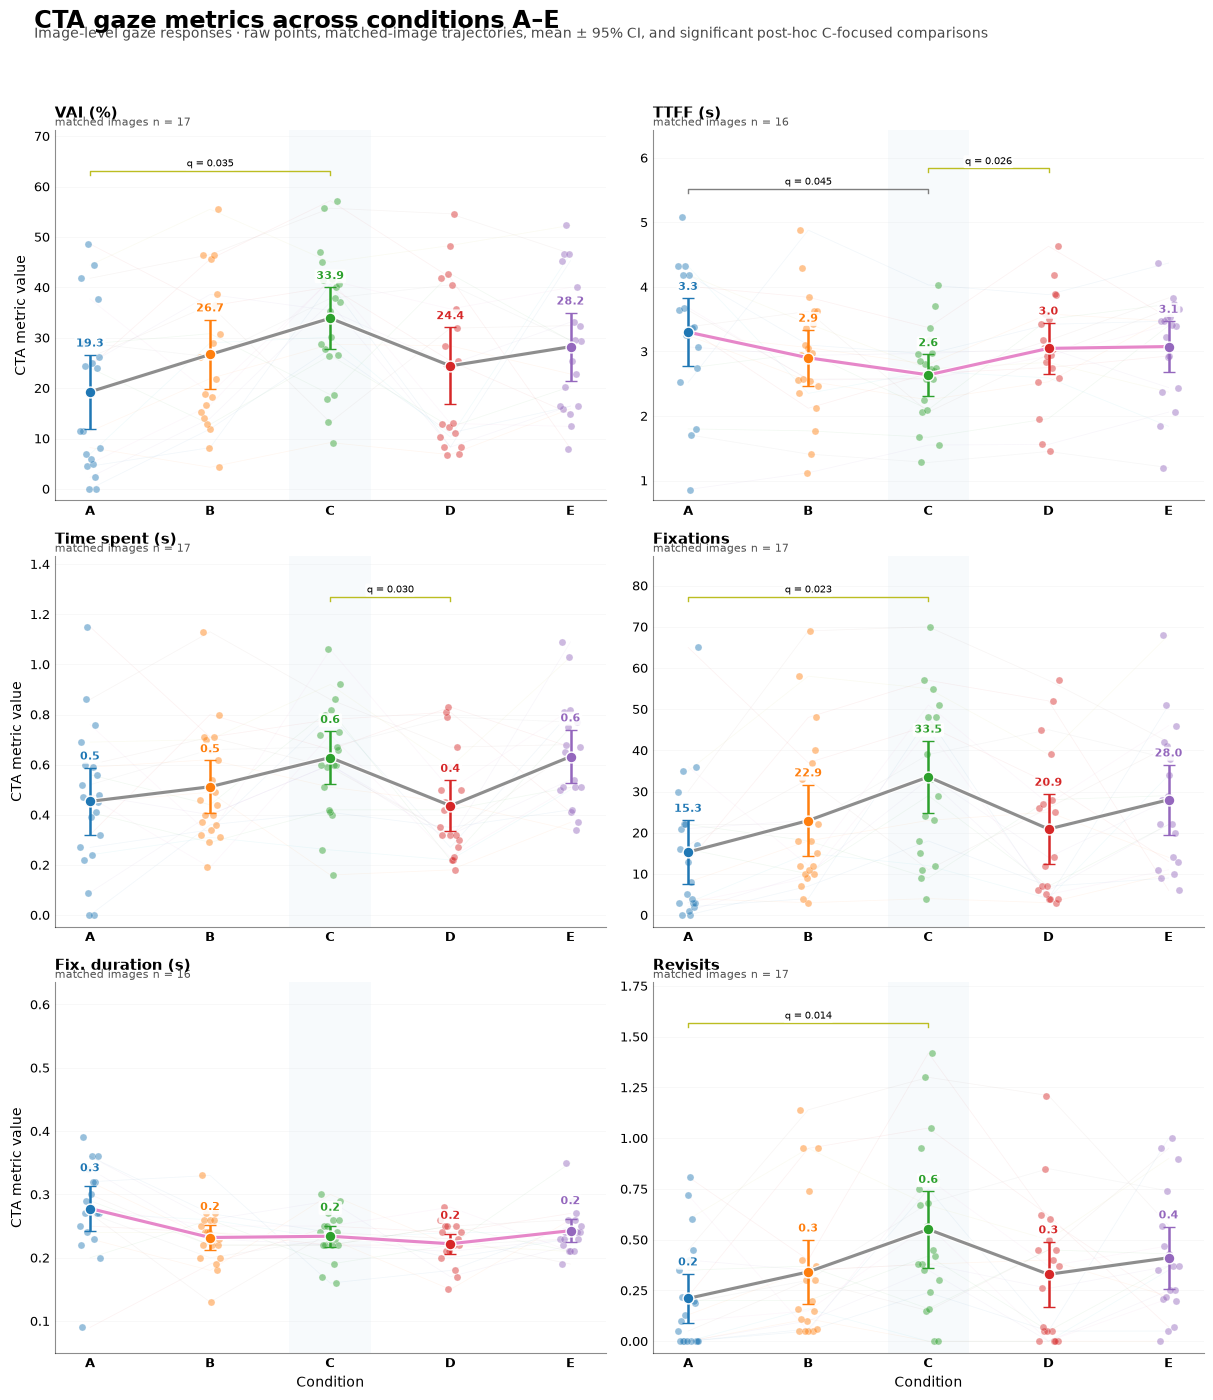

Saved: CTA_6metrics_modern_same_design.png
Saved: CTA_6metrics_modern_same_design.pdf


In [6]:
plt.rcParams.update({
    "font.size": 9.5,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "axes.linewidth": 0.8,
})

# use the active matplotlib color cycle
cycle_colors = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
if len(cycle_colors) < len(CONDITION_ORDER):
    cycle_colors = [f"C{i}" for i in range(len(CONDITION_ORDER))]

condition_colors = {
    c: cycle_colors[i]
    for i, c in enumerate(CONDITION_ORDER)
}

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(12.8, 14.6)
)

axes = axes.flatten()

all_focus = []

for i, metric in enumerate(SELECTED_METRICS):
    focus = draw_metric_panel(
        axes[i],
        metric,
        idx=i,
        condition_colors=condition_colors
    )
    all_focus.append(focus)

# y-label only on left column
for ax in [axes[0], axes[2], axes[4]]:
    ax.set_ylabel(f"{AOI} metric value", fontsize=10)

# x-label only on bottom row
for ax in [axes[4], axes[5]]:
    ax.set_xlabel("Condition", fontsize=10)

# remove x-label from upper rows for cleaner layout
for ax in [axes[0], axes[1], axes[2], axes[3]]:
    ax.set_xlabel("")

fig.suptitle(
    f"{AOI} gaze metrics across conditions A–E",
    x=0.07,
    y=0.995,
    ha="left",
    fontsize=17,
    fontweight="bold"
)

fig.text(
    0.07,
    0.976,
    "Image-level gaze responses · raw points, matched-image trajectories, mean ± 95% CI, and significant post-hoc C-focused comparisons",
    fontsize=10,
    alpha=0.72
)

fig.tight_layout(rect=[0.04, 0.04, 0.995, 0.965])

fig.savefig(
    OUTPUT_PNG,
    dpi=500,
    bbox_inches="tight",
    facecolor="white"
)

fig.savefig(
    OUTPUT_PDF,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print("Saved:", OUTPUT_PNG)
print("Saved:", OUTPUT_PDF)


## 6. Notes

- This notebook keeps the **same visual structure** as your single-metric plot.
- It simply repeats that design across **6 selected metrics**.
- To make a Headline or Product figure, change:

```python
AOI = "Headline"
```

or

```python
AOI = "Product"
```

- To change which 6 metrics appear, edit `SELECTED_METRICS`.
